# Agent 批量结果与独立复核
## 当前状态
两个快速模型独立标注全部符合条件的学生回合；两个强模型在固定分层随机子集和高风险回合独立复核。
原始输入部分读取显式选定、哈希固定的 `frozen` 快照；后半部读取 `results/final-analysis/` 的聚合表。所有单元离线计算，不发起模型调用。

## 范围与方法
单位为 08 本定义的学生 Q 回合；12 条工程合成控制与真实回合分列。若冻结时仍有未完成任务，
所有比例明确保留计划分母和已完成分母，未完成不会计入弃权。
### 关键假设
一致性只在同题、双模型均产生结构化输出的配对子集计算；另列双方都有数字标签的分母。
强模型的复核子集受到风险路由与分层抽样影响，不能把两组一致率差写成互评收益或准确率变化。

<!-- concept-illustration-v1:model-review -->
### 独立判断与复核

![两个基础模型独立判断，同题随机或风险复核进入两个独立复核模型，配对复跑另测稳定性](../assets/illustrations/model-review.png)

两基础模型与两复核模型分别独立判断任务、贡献两维。随机复核、风险复核和配对复跑保留各自分母；结论可继续弃权或保留争议。模型一致性与重复性各有对应统计量。

In [1]:
from pathlib import Path
import sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "aiv").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aiv.notebook_materials import (
    configure_style, save_figure, export_table, research_inputs,
    final_archive_summary, load_frozen_batch, load_turn_snapshot, load_turn_plan, load_full_turn_materials,
    turn_manifest_summary, pending_results, offline_monthly, COLORS,
)
configure_style()
LIVE_API = False

## 冻结证据入口

In [2]:
batch = load_turn_snapshot()
if batch is None:
    display(Markdown("**待冻结接入：`notebooks/research-inputs.json` 的 `turn_snapshot` 尚为空。以下真实测评结论留空。**"))
    planned = load_turn_plan()
    if planned is not None:
        display(pd.DataFrame([{"学期": term, "计划真实回合": n,
                               "已完成真实回合": pd.NA, "状态": "待正式冻结"}
                              for term, n in planned["term_counts"].items()]))
        display(Markdown(f"固定计划：{planned['planned_real']:,} 个真实回合，"
                         f"{planned['planned_controls']} 条控制；复跑计划 "
                         f"{planned['repeat_expected_tasks']} 次请求。未完成数和弃权数待冻结核定。"))
else:
    display(pd.DataFrame([{"批次": batch["experiment"], "修订": batch["revision"],
                           "冻结状态": batch["status"], "已完成真实回合": batch["completed_real"],
                           "计划真实回合": batch["planned_real"],
                           "快照清单": batch["source"], "清单 SHA-256": batch["source_sha256"]}]))
    display(Markdown("**解释口径：**下列表格只描述模型候选标签、弃权、执行与配对一致性；并非独立人工真值或学习效果。"))

**待冻结接入：`notebooks/research-inputs.json` 的 `turn_snapshot` 尚为空。以下真实测评结论留空。**

## A：覆盖、未完成与候选标签

In [3]:
coverage = pd.DataFrame(columns=["term", "planned", "completed", "candidate_labeled", "unknown_or_abstained", "unfinished", "completed_fraction", "labeled_among_completed"])
labels = pd.DataFrame(columns=["label", "completed_records"])
if batch is not None:
    coverage = pd.DataFrame(batch["by_term"])
    coverage["completed_fraction"] = coverage.completed / coverage.planned
    coverage["labeled_among_completed"] = coverage.candidate_labeled / coverage.completed.replace(0, np.nan)
    labels = pd.DataFrame([{"label": "候选 L" + label if label != "None" else "弃权/未知",
                            "completed_records": n} for label, n in batch["label_counts"].items()])
    labels = labels.sort_values("label").reset_index(drop=True)
display(coverage)
display(labels)
export_table(coverage, "agent-coverage")
export_table(labels, "agent-labels")
if batch is not None:
    fig, ax = plt.subplots(figsize=(8.8, 4.4))
    by_term = coverage.set_index("term")
    x = np.arange(len(by_term))
    ax.bar(x - .18, by_term.planned, width=.36, color="#D9E0E4", label="计划回合（含未完成）")
    ax.bar(x + .18, by_term.completed, width=.36, color="#176B77", label="已完成回合")
    ax.set_xticks(x, by_term.index)
    for i, row in enumerate(coverage.itertuples()):
        ax.text(i, row.planned + max(.1, coverage.planned.max()*.02),
                f"{row.completed}/{row.planned}", ha="center")
    ax.set(ylim=(0, max(coverage.planned)*1.16), ylabel="学生 Q 回合数",
           title="冻结快照的完成范围（分母为全部计划回合）")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_figure(fig, "real-turn-batch-coverage", "两学期的计划与已完成回合；未完成不计入弃权。",
                kind="real", sources=[batch["source"]], notebook="09_Agent批量结果与互评.ipynb")
    plt.show()

,term,planned,completed,candidate_labeled,unknown_or_abstained,unfinished,completed_fraction,labeled_among_completed


,label,completed_records


候选标签分布仅以已完成回合为范围；弃权/未知单列。任何未完成回合都保留在计划分母中，不能据已完成子集推断全体比例。

## A：独立模型与复核配对

In [4]:
paired = pd.DataFrame(columns=["stage", "dimension", "paired_structured", "same_including_abstain", "paired_labeled", "same_labeled", "labeled_agreement"])
stages = pd.DataFrame(columns=["stage", "requested", "valid", "failed", "unfinished"])
if batch is not None:
    paired = pd.DataFrame(batch["agreement"])
    stages = pd.DataFrame([{"stage": stage, **values,
                            "unfinished": values["requested"] - values["valid"] - values["failed"]}
                           for stage, values in batch["stages"].items()])
display(paired)
display(stages)
export_table(paired, "agent-independent-review")
export_table(stages, "agent-stage-coverage")
if batch is not None and paired.paired_labeled.max() > 0:
    fig, ax = plt.subplots(figsize=(9.2, 4.5))
    subset = paired[paired.dimension.eq("task")]
    xpos = np.arange(len(subset))
    ax.bar(xpos, subset.paired_labeled, color=["#176B77", "#BC632F"])
    for x, row in zip(xpos, subset.itertuples()):
        ax.text(x, row.paired_labeled + max(1, subset.paired_labeled.max()*.04),
                f"一致 {row.same_labeled}/{row.paired_labeled}", ha="center")
    ax.set_xticks(xpos, ["两快独立判断", "两强独立复核"])
    ax.set(ylim=(0, subset.paired_labeled.max()*1.23),
           ylabel="双方均给数字标签的配对回合数", title="同一阶段内的数字标签配对分母")
    fig.tight_layout()
    save_figure(fig, "real-paired-label-coverage", "同阶段双方均给数字任务标签的配对数；强模型子集按抽样和风险路由选择。",
                kind="real", sources=[batch["source"]], notebook="09_Agent批量结果与互评.ipynb")
    plt.show()

,stage,dimension,paired_structured,same_including_abstain,paired_labeled,same_labeled,labeled_agreement


,stage,requested,valid,failed,unfinished


两强模型处理的是选定子集，而非全部回合；上图比较分母与一致数量，不作阶段间因果比较。双方同弃权计入结构化一致列，但不计入数字标签一致率。

## D：重复稳定性与调用账本

In [5]:
repeat = pd.DataFrame(columns=["model", "dimension", "comparable", "equal", "stability"])
execution = pd.DataFrame(columns=["metric", "value"])
if batch is not None:
    repeat = pd.DataFrame(batch["repeat"])
    ledger = batch["ledger"]
    execution = pd.DataFrame([
        ["API 尝试数（账本合计）", sum(x["attempts"] for x in ledger)],
        ["已报告输入 token", sum(x["input_tokens"] or 0 for x in ledger)],
        ["已报告输出 token", sum(x["output_tokens"] or 0 for x in ledger)],
        ["用量未知的尝试数", sum(x["unknown_usage_attempts"] for x in ledger)],
        ["工程合成控制完成数", batch["completed_controls"]],
        ["工程合成控制计划数", batch["planned_controls"]],
        ["预选随机复核回合", batch["review_random_preselected"]],
        ["最终纳入复核回合", batch["review_selected_real"]],
    ], columns=["metric", "value"])
display(repeat)
display(execution)
export_table(repeat, "agent-repeat-stability")
export_table(execution, "agent-execution")

,model,dimension,comparable,equal,stability


,metric,value


重复稳定性仅对同模型同题两次都有结构化输出者计算。token 合计只覆盖服务方报告用量的尝试，未核价格不填写货币成本。合成控制用于工程合同检查，不当作人工金标准。

## 冻结派生分析：状态、复核分层与评分可用性

In [6]:
materials = load_full_turn_materials()
if materials is None:
    display(Markdown("派生分析包待接入。学生级指标和分层复核结果尚不填入。"))
else:
    summary = materials["summary"]
    denominators = pd.DataFrame(summary["denominators"].items(), columns=["口径", "数量"])
    display(denominators)
    export_table(denominators, "full-turn-denominators")
    fast_agreement = pd.DataFrame([{"维度": dimension,
        "双有效": values["both_valid"], "双非空": values["both_nonnull"],
        "学生簇": values["student_clusters_dual_nonnull"],
        "六级κ": values["kappa6"], "六级κ区间": values["kappa6_cluster_interval95"],
        "三阶κ": values["kappa3"], "三阶κ区间": values["kappa3_cluster_interval95"]}
        for dimension, values in summary["independent_agreement"].items()])
    display(fast_agreement)
    export_table(fast_agreement, "full-turn-fast-agreement")
    display(Markdown("两快一致性使用全部真实回合的双有效输出；不要求后续复核和复跑均已结算。κ 的分母为双方非空标签，区间按学生整簇重采样。相同输入的精确缓存可能使不同学生共享同一次模型响应；该区间未消除这类跨簇依赖，不能视为独立调用或准确率的置信区间。跨学生缓存链接数量以独立缓存核验收据为准。"))
    status_names = {"agreed": "候选", "abstained": "一致弃权", "disagreement": "分歧",
                    "uncertain": "不确定", "technical_failure": "技术失败"}
    status = pd.DataFrame([{"状态": label,
        "任务": summary["final_task_status_counts"].get(key, 0),
        "贡献": summary["final_contribution_status_counts"].get(key, 0)}
        for key, label in status_names.items()])
    assert status.任务.sum() == status.贡献.sum() == summary["denominators"]["completed_real"]
    display(status)
    export_table(status, "full-turn-final-status")
    fig, ax = plt.subplots(figsize=(9.2, 4.7))
    x = np.arange(len(status))
    a = ax.bar(x-.18, status.任务, width=.36, color="#176B77", label="任务要求")
    b = ax.bar(x+.18, status.贡献, width=.36, color="#BC632F", label="学生贡献")
    ax.bar_label(a, padding=3, fontsize=9)
    ax.bar_label(b, padding=3, fontsize=9)
    ax.set_xticks(x, status.状态)
    ax.set(ylabel="已完成真实回合数", title="任务与贡献的完成状态；未完成不在本图分母中")
    ax.set_ylim(0, max(status.任务.max(), status.贡献.max(), 1)*1.18)
    ax.legend(frameon=False)
    fig.tight_layout()
    save_figure(fig, "real-full-turn-final-status", "两个维度各以已完成真实回合为分母；技术失败与弃权分列。",
                kind="real", sources=[materials["source"], batch["source"]], notebook="09_Agent批量结果与互评.ipynb")
    plt.show()

派生分析包待接入。学生级指标和分层复核结果尚不填入。

## 分层复核及复跑的固定请求分母

In [7]:
if materials is not None:
    review_rows = []
    names = {"random_audit": "分层随机复核", "high_risk": "高风险复核", "control": "工程控制"}
    for key, name in names.items():
        item = materials["review_strata"]["strata"][key]
        task = item["review_tasks"]
        agreement = item["agreement"]["task"]
        review_rows.append({"来源": name, "计划回合": item["planned_records"],
                            "应有请求": task["expected"], "有效输出": task["valid"],
                            "失败": task["failed"], "排队或运行": task["pending"],
                            "未创建": task["not_created"], "双非空": agreement["both_nonnull"],
                            "六级κ": agreement["kappa6"], "三阶κ": agreement["kappa3"]})
    review_view = pd.DataFrame(review_rows)
    display(review_view)
    export_table(review_view, "full-turn-review-strata")
    repeats = materials["repeatability"]
    display(pd.DataFrame([{"计划回合": repeats["planned_records"], "应有请求": repeats["expected_tasks"],
                           **repeats["tasks"]}]))
    repeat_rows = []
    for model, item in repeats["by_model"].items():
        for dimension in ("task", "contribution"):
            repeat_rows.append({"模型": model, "维度": dimension, **item[dimension]})
    repeat_view = pd.DataFrame(repeat_rows)
    display(repeat_view)
    export_table(repeat_view, "full-turn-repeat-fixed-denominator")
    availability = pd.DataFrame(materials["summary"]["score_availability"].items(), columns=["字段", "可用行数"])
    display(availability)
    export_table(availability, "full-turn-score-availability")

随机复核用于既定抽样范围的检验；高风险子集包含选取机制，单独报告。复跑应有请求固定为预选回合×两个快模型，未创建请求不消失。候选会话尚不等于验证过的相邻边，完整 AIV 与排名仍由字段可用性决定。

## B/C/E：下游结论边界

In [8]:
pending = pending_results(batch, materials)
pending_view = pending[["item", "status", "estimate", "denominator", "dependency"]].rename(columns={"item": "结果", "status": "状态", "estimate": "数值", "denominator": "分母", "dependency": "依据或下一项条件"})
display(pending_view.astype(object).where(pending_view.notna(), "—"))
export_table(pending, "pending-results")
if batch is None:
    assert coverage.empty and paired.empty and repeat.empty and execution.empty
    assert pending.estimate.isna().all() and pending.denominator.isna().all()
assert LIVE_API is False

,结果,状态,数值,分母,依据或下一项条件
0,真实回合结算完成率,待接入,—,—,等待冻结批次的结算完成数与计划数
1,两快独立标注与两强独立复核,待接入,—,—,等待分阶段配对分母与冻结输出
2,同模型重复稳定性,待接入,—,—,等待可比较的重复调用
3,调用账本与 token,待接入,—,—,等待冻结运行账本
4,真实任务层级分布,待接入,—,—,等待冻结标签；说明抽样范围
5,真实总体校准结果,待接入,—,—,需要独立人工参考标签及适用的抽样设计
6,真实会话转移质量 CTQ,当前不可识别,—,—,需要经核验的相邻回合、会话边界与时间顺序
7,完整真实 AIV 与排名,当前不可识别,—,—,需要五项指标的完整可观测性及误差审计
8,独立学习增量,当前不可识别,—,—,目前缺少独立学习结果与识别设计


候选标签从 A 输入 B/C，但不能填补独立学习结果、可比对照或缺失工具字段。C 的完整真实 AIV 与排名仍需各指标可观测及误差界；E 只能生成与证据范围相称的建议。

## 真实观察：六级分布与同回合双维比较
任务与贡献分别有 1,010 和 776 条候选，占全部 3,515 回合的不同子集。
边际分布用于描述各自候选；两维比较使用同一回合均有候选的 48 条记录。
来源：`descriptive.csv`、`level-distribution.csv`、`joint-levels.csv` 与 `summary.json`，均位于 `results/final-analysis/`。

In [9]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aiv.notebook_materials import configure_style, save_figure
configure_style()
FINAL_DIR = ROOT / "results" / "final-analysis"
_final_summary_path = FINAL_DIR / "summary.json"
final_summary = json.loads(_final_summary_path.read_text(encoding="utf-8")) if _final_summary_path.is_file() else None

def final_csv(name):
    return pd.read_csv(FINAL_DIR / name) if final_summary is not None else pd.DataFrame()

if final_summary is None:
    display(Markdown("本目录未附真实聚合分析；以下真实结果保持空白，前面的合成实验仍可复算。"))
else:
    display(pd.DataFrame([{
        "分析输入": "results/final-analysis/summary.json",
        "冻结修订": final_summary["source"]["revision"],
        "快照清单 SHA-256": final_summary["source"]["manifest_sha256"],
        "真实回合": final_summary["denominators"]["real_turns"],
        "学生—学期": final_summary["denominators"]["student_terms"],
    }]))

,分析输入,冻结修订,快照清单 SHA-256,真实回合,学生—学期
0,results/final-analysis/summary.json,t3,7e885ceecf12a180349369ed9ddfc962ad71f1ea270f68...,3515,401


,term,dimension,turns,students,candidate_turns,candidate_students,students_without_candidates,candidate_coverage,turn_weighted_abl_raw,equal_student_abl_raw,turn_weighted_hot,equal_student_hot
0,all,task,3515,401,1010,356,45,0.2873,2.2703,2.2868,0.1554,0.1496
1,all,contribution,3515,401,776,244,157,0.2208,2.8711,2.7446,0.3531,0.3170
2,25f,task,2509,295,661,257,38,0.2635,2.5537,2.5566,0.1952,0.1858
3,25f,contribution,2509,295,621,190,105,0.2475,2.9533,2.8187,0.3784,0.3429
4,26s,task,1006,106,349,99,7,0.3469,1.7335,1.5864,0.0802,0.0556
5,26s,contribution,1006,106,155,54,52,0.1541,2.5419,2.4840,0.2516,0.2257


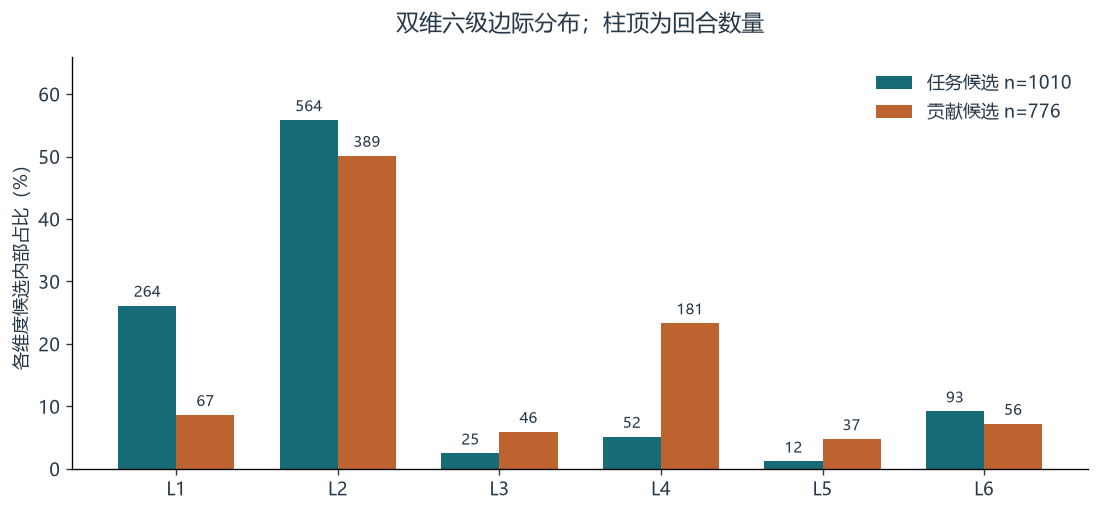

In [10]:
if final_summary is not None:
    descriptive = final_csv("descriptive.csv")
    level_distribution = final_csv("level-distribution.csv")
    display(descriptive[["term", "dimension", "turns", "students", "candidate_turns", "candidate_students", "students_without_candidates", "candidate_coverage", "turn_weighted_abl_raw", "equal_student_abl_raw", "turn_weighted_hot", "equal_student_hot"]].round(4))
    levels_all = level_distribution.loc[level_distribution.term.eq("all")]
    fig, ax = plt.subplots(figsize=(9.3, 4.4))
    for shift, dimension, label, color in [(-.18, "task", "任务候选", "#176B77"), (.18, "contribution", "贡献候选", "#BC632F")]:
        group = levels_all.loc[levels_all.dimension.eq(dimension)].sort_values("level")
        assert group["count"].sum() == group.candidate_denominator.iloc[0]
        bars = ax.bar(group.level+shift, 100*group.candidate_share, width=.36, color=color, label=f"{label} n={int(group.candidate_denominator.iloc[0])}")
        ax.bar_label(bars, labels=[str(int(n)) for n in group["count"]], padding=3, fontsize=9)
    ax.set_xticks(range(1, 7), [f"L{x}" for x in range(1, 7)])
    ax.set(ylim=(0, levels_all.candidate_share.max()*118), ylabel="各维度候选内部占比（%）", title="双维六级边际分布；柱顶为回合数量")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_figure(fig, "final-dimension-level-distribution", "各维度分别以自身候选为分母；两个候选集合并非同一批回合。", kind="real", sources=["results/final-analysis/level-distribution.csv", "results/final-analysis/descriptive.csv", "results/final-analysis/summary.json"], notebook="09_Agent批量结果与互评.ipynb")
    plt.show()

按回合加权回答“候选回合的平均标签”；按有候选的学生—学期等权回答“这些学生—学期的平均标签”。
无候选的学生—学期另列，两个加权结果都不能外推为全部学生能力。

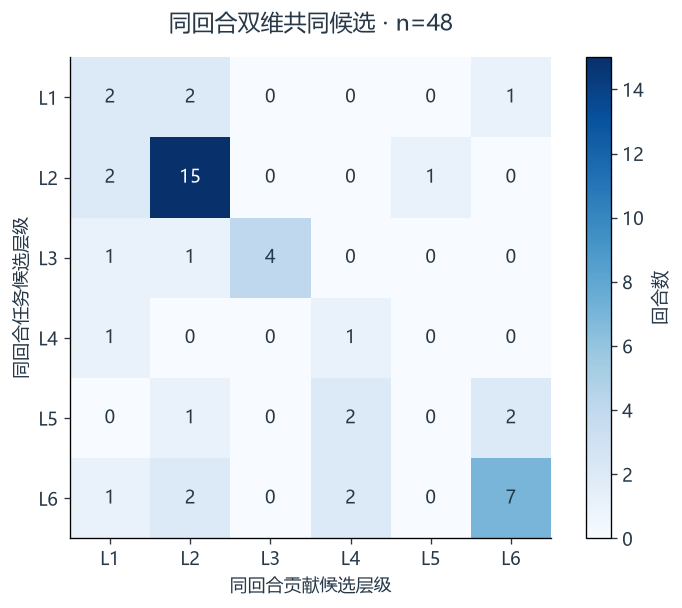

,共同候选,任务较高,相同,贡献较高,任务高阶且贡献非高阶
0,48,13,29,6,5


In [11]:
if final_summary is not None:
    joint_levels = final_csv("joint-levels.csv")
    joint_all = joint_levels.loc[joint_levels.term.eq("all")]
    joint_matrix = joint_all.pivot(index="task_level", columns="contribution_level", values="count").reindex(index=range(1, 7), columns=range(1, 7)).fillna(0).astype(int)
    assert joint_matrix.to_numpy().sum() == final_summary["joint"]["paired_denominator"] == 48
    fig, ax = plt.subplots(figsize=(6.6, 5.2))
    im = ax.imshow(joint_matrix.to_numpy(), cmap="Blues", vmin=0, aspect="equal")
    for y in range(6):
        for x in range(6):
            value = joint_matrix.iloc[y, x]
            ax.text(x, y, str(value), ha="center", va="center", color="white" if value > joint_matrix.to_numpy().max()*.55 else "#273949")
    ax.set_xticks(range(6), [f"L{x}" for x in range(1, 7)])
    ax.set_yticks(range(6), [f"L{x}" for x in range(1, 7)])
    ax.set(xlabel="同回合贡献候选层级", ylabel="同回合任务候选层级", title="同回合双维共同候选 · n=48")
    fig.colorbar(im, ax=ax, label="回合数")
    fig.tight_layout()
    save_figure(fig, "final-joint-candidate-levels", "48条同回合双维非空候选；任务较高13条、相同29条、贡献较高6条。", kind="real", sources=["results/final-analysis/joint-levels.csv", "results/final-analysis/summary.json"], notebook="09_Agent批量结果与互评.ipynb")
    plt.show()
    joint = final_summary["joint"]
    display(pd.DataFrame([{"共同候选": joint["paired_denominator"], "任务较高": joint["task_above_contribution"], "相同": joint["equal"], "贡献较高": joint["task_below_contribution"], "任务高阶且贡献非高阶": joint["task_hot_contribution_not_hot"]}]))

同回合比较得到任务较高 13 条、相同 29 条、贡献较高 6 条，共 48 条。
共同候选仅占全部回合的一小部分；双维边际均值之差不等于这 48 条同回合差值，也不能用来判断全部学生的任务与贡献差距。